In [ ]:
# Hosted D2L setup: fetch the exact helper module used to build this notebook.
from pathlib import Path
from urllib.request import urlretrieve
from importlib.metadata import PackageNotFoundError, version
import importlib.util, os, subprocess, sys

required = ['numpy', 'pandas', 'matplotlib', 'requests', 'scipy', 'pillow', 'regex', 'jax', 'jaxlib', 'flax', 'optax', 'orbax-checkpoint', 'tensorflow', 'protobuf', 'ml-dtypes', 'gymnasium']
imports = {'pillow': 'PIL', 'orbax-checkpoint': 'orbax', 'protobuf': 'google.protobuf', 'ml-dtypes': 'ml_dtypes'}
pinned = {'jax': ('0.10.2', 'jax==0.10.2', 'jax[cuda12]==0.10.2', 'exact'), 'jaxlib': ('0.10.2', 'jaxlib==0.10.2', 'jaxlib==0.10.2', 'exact'), 'flax': ('0.12.7', 'flax==0.12.7', 'flax==0.12.7', 'exact'), 'optax': ('0.2.8', 'optax==0.2.8', 'optax==0.2.8', 'exact'), 'orbax-checkpoint': ('0.12.0', 'orbax-checkpoint==0.12.0', 'orbax-checkpoint==0.12.0', 'exact'), 'gymnasium': ('1.2.3', 'gymnasium[toy-text]==1.2.3', 'gymnasium[toy-text]==1.2.3', 'exact')}
fallbacks = {'tensorflow': 'tensorflow==2.21.0', 'protobuf': 'protobuf==7.34.1', 'ml-dtypes': 'ml-dtypes==0.5.4'}
device = os.environ.get("D2L_HOSTED_DEVICE", "auto").lower()
if device not in ("auto", "cpu", "gpu"):
    raise ValueError(f"Invalid D2L_HOSTED_DEVICE={device!r}")
if device == "auto":
    try:
        gpu = (Path("/dev/nvidia0").exists() or
               subprocess.run(["nvidia-smi", "-L"], capture_output=True,
                              timeout=5).returncode == 0)
    except (FileNotFoundError, subprocess.SubprocessError):
        gpu = False
else:
    gpu = device == "gpu"
if not gpu:
    os.environ.setdefault("CUDA_VISIBLE_DEVICES", "-1")
    os.environ.setdefault("JAX_PLATFORMS", "cpu")
tensorflow_version = None
if 'jax' in ("tensorflow", "jax"):
    try:
        tensorflow_version = version("tensorflow")
    except PackageNotFoundError:
        pass
# Colab's CPU image currently carries a CUDA-enabled TensorFlow wheel. Its
# first ordinary tensor operation probes CUDA and emits an error-level cuInit
# diagnostic. JAX notebooks also use TensorFlow for data loading, so overlay
# the matching CPU build in both CPU variants. Keep the provider's
# ``tensorflow`` distribution metadata: other preinstalled Colab packages
# depend on that distribution name, while both wheels expose the same module.
if not gpu and 'jax' in ("tensorflow", "jax"):
    try:
        tensorflow_cpu_version = version("tensorflow-cpu")
    except PackageNotFoundError:
        tensorflow_cpu_version = None
    if (tensorflow_version is not None and
            tensorflow_cpu_version != tensorflow_version):
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", "--no-deps",
            f"tensorflow-cpu=={tensorflow_version}",
        ])
if "tf-keras" in fallbacks and tensorflow_version is not None:
    fallbacks["tf-keras"] = f"tf-keras=={tensorflow_version}"
missing = []
for package in required:
    if package in pinned:
        wanted, cpu_requirement, gpu_requirement, match = pinned[package]
        requirement = gpu_requirement if gpu else cpu_requirement
        try:
            installed = version(package)
        except PackageNotFoundError:
            installed = None
        actual = (installed.split("+", 1)[0]
                  if installed is not None and match == "public" else installed)
        if actual != wanted:
            missing.append(requirement)
    elif importlib.util.find_spec(imports.get(package, package)) is None:
        missing.append(fallbacks.get(package, package))
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

mismatched = []
for package, (wanted, _, _, match) in pinned.items():
    try:
        installed = version(package)
    except PackageNotFoundError:
        installed = None
    actual = (installed.split("+", 1)[0]
              if installed is not None and match == "public" else installed)
    if actual != wanted:
        mismatched.append(f"{package}={installed!r} (expected {wanted})")
if mismatched:
    raise RuntimeError("Hosted runtime setup failed: " + ", ".join(mismatched))

root = Path(".d2l-hosted") / "0114bae219d4d94bc9d18a2e1ab76c089e2dc890"
package = root / "d2l"
package.mkdir(parents=True, exist_ok=True)
base = "https://raw.githubusercontent.com/smolix/d2l-neu/0114bae219d4d94bc9d18a2e1ab76c089e2dc890/d2l"
for name in ('__init__.py', 'jax.py'):
    target = package / name
    if not target.exists():
        urlretrieve(f"{base}/{name}", target)
if str(root.resolve()) not in sys.path:
    sys.path.insert(0, str(root.resolve()))
pythonpath = os.environ.get("PYTHONPATH", "").split(os.pathsep)
if str(root.resolve()) not in pythonpath:
    os.environ["PYTHONPATH"] = os.pathsep.join(
        [str(root.resolve()), *[entry for entry in pythonpath if entry]]
    )


# Trust Regions and Proximal Policy Optimization

Policy-gradient methods update parameters $\theta$, but the same parameter displacement can produce very different changes in the distribution $\pi_\theta(\cdot\mid s)$. Large policy changes can invalidate the data used to estimate an update and can move an on-policy learner into a poor data-collection regime. We begin with a two-action example that makes this mismatch explicit.

Trust-region methods constrain change in policy space rather than parameter space [@Schulman.Levine.Abbeel.ea.2015]. Proximal Policy Optimization (PPO) replaces the explicit constraint with a clipped surrogate objective and reuses each on-policy batch for several updates [@Schulman.Wolski.Dhariwal.ea.2017]. This section derives importance-ratio correction, relates trust regions to the performance-difference lemma, and evaluates clipping through training curves and policy-drift diagnostics.

In [1]:
%matplotlib inline
from d2l import jax as d2l
from flax import nnx
import gymnasium as gym
import jax
from jax import numpy as jnp
import numpy as np

## Parameter Space versus Policy Space

Since we now update the parameters of the policy directly, we should ask what a parameter update does to the policy itself. A family of policies with a single parameter $\theta$ and two actions answers it; we borrow the example from Joshua Achiam's lectures on policy optimization [@Achiam.2017]. Let

$$\pi_\theta(a) = \begin{cases} \sigma(\theta) & a = 1 \\ 1 - \sigma(\theta) & a = 2, \end{cases} \qquad \textrm{where } \sigma(\theta) = \frac{1}{1 + e^{-\theta}}.$$

Take two parameter updates of exactly the same size, $\Delta\theta = 2$, from two different starting points:

$$\pi_{\theta=0}(a{=}1) = \sigma(0) = 0.50 \ \xrightarrow{\ \Delta\theta = 2\ }\ \sigma(2) = 0.88, \qquad \pi_{\theta=6}(a{=}1) = \sigma(6) = 0.9975 \ \xrightarrow{\ \Delta\theta = 2\ }\ \sigma(8) = 0.9997.$$

The first update takes the agent from indifferent between the two actions to strongly committed to one of them, a drastic change in behavior. The second changes nothing that an observer of the agent could detect. the figure plots the map from parameter to policy with both updates drawn on it, and, beside it, the two action distributions before and after each update.

![Two parameter updates of the same size, $\Delta\theta = 2$. Left: the map $\pi_\theta(a{=}1) = \sigma(\theta)$ with both updates drawn on it; from $\theta = 0$ the policy moves by $0.38$, from $\theta = 6$ by $0.002$, and the annotated derivatives $\sigma'(0) = 0.25$ and $\sigma'(6) \approx 0.0025$ say why. Right: the same two updates as action distributions before and after; the left update rewrites the policy, the right update does not visibly change it.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-rl-policy-vs-parameter.svg)

Both updates change $\theta$ by two. Starting from $\theta=0$, the action probability changes from $0.50$ to $0.88$; starting from $\theta=6$, it changes from $0.9975$ to $0.9997$. Equal distances in parameter space can therefore correspond to very different distances between policies.

The derivative $\sigma'(\theta)=\sigma(\theta)(1-\sigma(\theta))$ is $0.25$ at $\theta=0$ and about $0.0025$ at $\theta=6$. A parameter step therefore has much greater effect near an even policy than near a saturated one.

This variation can make on-policy training difficult. A large noisy update near $\theta=0$ may move the policy into saturation. The frequently selected action then has an almost-zero score, while the alternative action has an informative score but is sampled rarely. As a result, later on-policy batches may provide too little evidence to reverse the update. Limiting Euclidean distance in parameter space does not directly limit this change in behavior.

The update should therefore constrain a distance between policies rather than a Euclidean distance between parameters. Within this constraint, the optimizer can take a large parameter step when it produces only a small policy change and can reuse a batch for several updates.

## Reusing Data with Importance Sampling

### The Change of Measure

Every estimator since that section has used trajectories sampled from the current policy. After one gradient step, that batch was treated as stale, which made policy-gradient learning expensive in environment interactions. Suppose instead that the batch was collected by an earlier policy $\pi_{\theta_{\textrm{old}}}$. How can it be used to evaluate an updated policy $\pi_\theta$?

Importance sampling gives the exact answer. For any function $f$ of trajectories,

$$E_{\tau \sim P(\cdot;\, \theta)} \big[ f(\tau) \big] = \sum_\tau P(\tau; \theta)\, f(\tau) = \sum_\tau P(\tau; \theta_{\textrm{old}})\ \frac{P(\tau; \theta)}{P(\tau; \theta_{\textrm{old}})}\, f(\tau) = E_{\tau \sim P(\cdot;\, \theta_{\textrm{old}})} \Big[ \frac{P(\tau; \theta)}{P(\tau; \theta_{\textrm{old}})}\, f(\tau) \Big],$$

valid whenever every trajectory the new policy can produce has positive probability under the old one, a condition softmax policies satisfy automatically because they never assign zero probability to any action. Applied with $f = R$, the return, this rewrites the objective of that section as an expectation under the *old* policy,

$$J(\theta) = E_{\tau \sim P(\cdot;\, \theta)} \big[ R(\tau) \big] = E_{\tau \sim P(\cdot;\, \theta_{\textrm{old}})} \Big[ \frac{P(\tau; \theta)}{P(\tau; \theta_{\textrm{old}})}\, R(\tau) \Big],$$

Thus data from the old policy give an unbiased estimate of the new policy's return when weighted by the trajectory likelihood ratio. Expanding $P(\tau;\theta)$ from the equation cancels the transition probabilities between numerator and denominator, just as in that section. The remaining weight is a product of policy ratios:

$$\frac{P(\tau; \theta)}{P(\tau; \theta_{\textrm{old}})} = \prod_{t=0}^{T-1} \frac{\pi_\theta(a_t \mid s_t)}{\pi_{\theta_{\textrm{old}}}(a_t \mid s_t)}.$$

### The Exploding Product of Ratios

Although the estimator is unbiased, its variance can be prohibitive. Each ratio is nonnegative and unbounded above, and multiplying ratios across a long trajectory can produce weights spanning many orders of magnitude. A trajectory that is rare under the old policy and common under the new one can then dominate the estimate. The variance of the exact correction the equation generally grows with the horizon.

### The Per-Step Surrogate

The practical compromise keeps one ratio per step. Define

$$\rho_t(\theta) = \frac{\pi_\theta(a_t \mid s_t)}{\pi_{\theta_{\textrm{old}}}(a_t \mid s_t)}$$

and optimize the sampled surrogate objective

$$\hat{L}(\theta) = \frac{1}{n} \sum_{i=1}^n \sum_{t} \rho_t^i(\theta)\ \hat{A}_t^i,$$

where $\hat{A}_t^i$ is an advantage estimate for step $t$ of trajectory $i$, such as the normalized reward-to-go of that section. Relative to the equation, this approximation replaces the product of ratios by one ratio per step and retains the old policy's state distribution. These choices reduce variance. The approximation is locally exact in the sense needed for optimization: at $\theta = \theta_{\textrm{old}}$, every ratio equals one and $\nabla_\theta \rho_t = \nabla_\theta \log \pi_\theta(a_t \mid s_t)$. Thus the equation has the correct policy gradient at the old parameters, but it may be inaccurate after a large policy change. This raises the next question: how should the size of that change be measured and controlled?

### The Length-Normalized Trajectory Ratio

A length-normalized trajectory ratio lies between the full product and the individual per-step ratios. Raising the product to the power $1/T$ gives its geometric mean, whose logarithm is the average per-step log-ratio and whose scale does not grow exponentially with sequence length. GSPO clips this sequence-level ratio rather than each per-step ratio in language-model training. that section returns to this construction for token trajectories.

## Bounding the Step

### The Performance Difference Lemma

To relate the surrogate to actual performance, abbreviate the old policy's advantage the equation as $A^{\textrm{old}}(s,a)=Q^{\pi_{\theta_{\textrm{old}}}}(s,a)-V^{\pi_{\theta_{\textrm{old}}}}(s)$. The performance difference lemma expresses the return of a candidate policy relative to the old policy:

**Proposition** (performance difference lemma, @Kakade.Langford.2002).

$$
J(\theta) - J(\theta_{\textrm{old}}) = E_{\tau \sim P(\cdot;\, \theta)} \Big[ \sum_{t=0}^{T-1} \gamma^t\, A^{\textrm{old}}(s_t, a_t) \Big].
$$

**Proof.** Write $V$ for $V^{\pi_{\theta_{\textrm{old}}}}$. Along any trajectory, the sum $\sum_t \gamma^t \big( r_t + \gamma V(s_{t+1}) - V(s_t) \big)$ telescopes: the interior $V$ terms cancel in pairs, and $V = 0$ at termination, leaving $R(\tau) - V(s_0)$. Now take expectations under $\tau \sim P(\cdot;\, \theta)$. On the left, conditioned on $(s_t, a_t)$, the expectation of $r_t + \gamma V(s_{t+1})$ over the next state is $Q^{\pi_{\theta_{\textrm{old}}}}(s_t, a_t)$, by the equation written with $V^\pi$, so each term becomes $\gamma^t\, E\big[ A^{\textrm{old}}(s_t, a_t) \big]$. On the right, $E[R(\tau)] = J(\theta)$, and $E[V(s_0)] = J(\theta_{\textrm{old}})$ because both policies draw $s_0$ from the same $\mu_0$. $\blacksquare$

The lemma says that improvement depends on the old policy's advantages evaluated along trajectories of the new policy. Those trajectories are unavailable until the candidate policy is deployed. Replacing their state distribution by the old policy's state distribution, and reweighting only the sampled actions by $\rho_t$, gives the surrogate in the equation after omitting the conventional factor $\gamma^t$. The approximation is exact at $\theta_{\textrm{old}}$ and deteriorates as the two policies induce different state distributions. Its accuracy therefore depends on policy change, not directly on parameter distance.

### Trust Regions and the Monotonic-Improvement Bound

Trust Region Policy Optimization answers with a constraint measured where the two-action example said it must be: in policy space. Maximize the surrogate, but keep the new policy close to the old one,

$$\max_\theta\ \hat{L}(\theta) \quad \textrm{subject to} \quad \frac{1}{n}\sum_{i,t} D_{\textrm{KL}}\big( \pi_{\theta_{\textrm{old}}}(\cdot \mid s_t^i)\ \Vert\ \pi_\theta(\cdot \mid s_t^i) \big) \leq \delta_{\textrm{KL}},$$

where the Kullback--Leibler divergence (that section) measures the change in the action distribution at each visited state. The monotonic-improvement result is stated for population quantities rather than a sampled batch. Let $\rho_{\textrm{old}}(s)=\sum_{t\geq0}\gamma^tP(s_t=s\mid\pi_{\theta_{\textrm{old}}})$ denote the old policy's discounted state-visitation measure, with total mass $1/(1-\gamma)$ in a continuing task, and define the population surrogate

$$\bar{L}(\theta) = \sum_s \rho_{\textrm{old}}(s) \sum_a \pi_\theta(a \mid s)\, A^{\textrm{old}}(s, a),$$

the sampled surrogate with every sample replaced by its expectation. Two facts distinguish the two quantities. First, $\bar{L}(\theta_{\textrm{old}})=0$ because the old policy's expected advantage vanishes at every state; the finite-sample $\hat{L}$ need not be zero there and also omits the $\gamma^t$ weights, as discussed after the equation. Second, the theoretical bound uses the largest divergence over all states, including states absent from a sampled batch. With $A_{\max} = \max_{s, a} \lvert A^{\textrm{old}}(s, a) \rvert$,

$$
J(\theta)\ \geq\ J(\theta_{\textrm{old}}) + \bar{L}(\theta)\ -\ \frac{4 \gamma A_{\max}}{(1-\gamma)^2}\ \max_s\, D_{\textrm{KL}}\big( \pi_{\theta_{\textrm{old}}}(\cdot \mid s)\ \Vert\ \pi_\theta(\cdot \mid s) \big),
$$

[@Kakade.Langford.2002; @Schulman.Levine.Abbeel.ea.2015]. At $\theta=\theta_{\textrm{old}}$, the bound holds with equality. Increasing its right-hand side therefore guarantees an increase in the true objective. TRPO makes three practical approximations: it replaces $\bar{L}$ by the sampled surrogate, replaces the worst-state divergence by an empirical mean over visited states, and selects a KL limit $\delta_{\textrm{KL}}$ instead of using the conservative theoretical coefficient. It then solves the constrained problem by second-order optimization. The constraint measures the update in policy space. Locally, KL divergence induces the Fisher metric, and the associated update is the natural gradient [@Amari.1998; @Kakade.2002]. The right panel of the figure compares this geometry with a Euclidean constraint.

![Bounding a policy update. Left: the surrogate $L$ is tangent to the true objective $J$ at $\theta_{\textrm{old}}$ but becomes inaccurate after a large policy change. Here the unconstrained maximizer of $L$ lowers $J$ from $0.82$ to $-0.38$, whereas the best point inside the shaded trust region raises it to $1.52$. Right: for a three-action softmax policy, the exact local constraint $D_{\textrm{KL}}\leq0.02$ is an ellipse in parameter space. Two parameter steps of equal Euclidean length produce KL divergences $0.008$ and $0.049$, so parameter distance does not determine policy distance.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-rl-trust-region.svg)

### The Clipped Objective

PPO replaces the second-order constrained optimization with a first-order clipped objective. Rather than clipping the ratios themselves, it limits the improvement attributed to ratios outside a prescribed interval:

$$L^{\textrm{CLIP}}(\theta) = \frac{1}{n} \sum_{i,t} \min\Big( \rho_t^i(\theta)\, \hat{A}_t^i,\ \ \textrm{clip}\big(\rho_t^i(\theta),\ 1-\epsilon,\ 1+\epsilon\big)\, \hat{A}_t^i \Big),$$

with a clipping parameter $\epsilon$, typically $0.2$. Consider one sample. If $\hat{A}_t > 0$, its contribution increases with $\rho_t$ only until $\rho_t = 1+\epsilon$; beyond this value, the clipped term is selected and its gradient is zero. If $\hat{A}_t < 0$, the corresponding threshold is $1-\epsilon$. The minimum is deliberately one-sided: a change that lowers the objective remains visible, whereas further movement in the favorable direction is no longer rewarded. The ratio itself is not clipped and can still cross the band because other samples share the same network parameters. Thus clipping is a soft incentive rather than a hard constraint. It nevertheless permits several epochs of optimization on a single batch without continually rewarding large changes in individual action probabilities.

![The one-sample clipped objective the equation as a function of $\rho_t(\theta)=\pi_\theta(a_t\mid s_t)/\pi_{\theta_{\textrm{old}}}(a_t\mid s_t)$. For positive advantage, the contribution stops increasing above $1+\epsilon$; for negative advantage, it stops increasing below $1-\epsilon$. Movement that lowers the surrogate remains visible on the unclipped side, so clipping is an asymmetric incentive rather than a hard ratio constraint.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-rl-ppo-clip.svg)

Unlike the TRPO bound in the equation, the clipped objective does not guarantee monotonic improvement. It is a first-order heuristic that discourages large changes in sampled action probabilities. The ablation below tests its effect empirically, and the subsequent diagnostics measure the policy changes that the theorem would otherwise constrain.

### Asymmetric Clipping Bands

A symmetric interval in ratio space permits different absolute probability changes. If the old policy assigns probability $0.01$ to an action, the upper ratio $1+\epsilon$ with $\epsilon=0.2$ stops rewarding increases above $0.012$. An action with probability $0.60$ may instead increase to $0.72$ within the same ratio interval. Low-probability actions therefore receive much smaller allowed changes in probability mass.

An asymmetric band uses $1-\epsilon_{\textrm{low}}$ and $1+\epsilon_{\textrm{high}}$, with $\epsilon_{\textrm{high}}>\epsilon_{\textrm{low}}$, to permit larger relative increases. Variants of this design appear in some recent language-model training recipes discussed near that section. It is not a standard component of PPO, and Exercise 7 examines its arithmetic.

### The Entropy Bonus

Implementations often add a small *entropy bonus*, `entropy_coef` times the mean entropy of the action distributions. The bonus discourages probabilities from concentrating near zero or one, where the frequently sampled action has a small score and recovery can become slow.

The function `ppo_epochs` adds this term and records policy entropy after each epoch, allowing saturation to be measured directly. that section shows that an entropy bonus is equivalent, up to a constant, to a KL penalty relative to a uniform reference policy.

## PPO in Practice

### The Choice of Advantage Estimate

Equation the equation accepts any declared advantage estimator.
Reward-to-go minus a learned baseline gives the Monte Carlo endpoint;
the TD error $\delta_t$ gives the one-step bootstrapped endpoint; and GAE
mixes depths using the telescoping identity the equation. This
$\delta_t$ is distinct from the trust-region radius
$\delta_{\textrm{KL}}$.

that section found the smallest one-draw error in its local
diagnostic near $\lambda=0.95$, also a common implementation default
[@Schulman.Moritz.Levine.ea.2016]. We use that value explicitly; it
is a heuristic setting, not a consequence of PPO's clipped objective.
The loop below is a full-batch teaching implementation. It preserves the
estimator equations but uses an update schedule chosen for legibility;
the final table lists the additional production choices it omits.

### The Implementation

We use the CartPole setup from that section, including the
`ActorCritic.mlp` model, batches of eight episodes, and `critic_steps` critic
updates. Three new hyperparameters determine the PPO update. We deliberately
use `num_epochs = 20` passes over each batch to make the effects of reuse
visible; `epsilon_clip = 0.2` sets the clipping interval, and
`entropy_coef = 0.01` weights the entropy bonus.

In [2]:
gamma, lam, num_updates, batch_episodes = 0.99, 0.95, 60, 8
num_seeds, num_epochs, critic_steps = 8, 20, 20
epsilon_clip, entropy_coef = 0.2, 0.01
def cartpole_agent(seed):
    return d2l.ActorCritic.mlp(4, 2, rngs=nnx.Rngs(seed))

Two pieces of per-framework speed first, not algorithm, both following the compilation rule of that section exactly as that section did: compile what has a fixed shape and runs hot. The acting forward is compiled and cached in the jax tab and stays eager in the pytorch tab; both tabs gain a batched probability read `_probs` that the vectorized collection at the end of the section will want.

In [3]:
_act_probs = nnx.jit(lambda net, obs: jax.nn.softmax(net(obs), -1))

def _probs(ac, obs):   # the fixed-shape acting forward, compiled and
    if not hasattr(ac, '_fwd'):    # cached as in :numref:`sec_actorcritic`
        ac._fwd = nnx.cached_partial(_act_probs, ac.policy)
    return np.asarray(ac._fwd(jnp.asarray(obs)))

@d2l.add_to_class(d2l.ActorCritic)
def act(self, obs, rng):
    p = _probs(self, obs)
    return int(rng.choice(len(p), p=p))

@d2l.add_to_class(d2l.ActorCritic)
def act_greedy(self, obs, rng=None):
    return int(_probs(self, obs).argmax())

The critic's regression is the same hot loop it was in that section, and the jax tab repeats that section's padding trick, batches padded to a power-of-two length so the jitted pass compiles once per size bucket; sections are self-contained, so the cell is repeated rather than imported.

In [4]:
def _pad(x, size):
    return jnp.asarray(np.pad(x, ((0, size - len(x)),) + ((0, 0),)
                              * (x.ndim - 1)))

_value_fwd = nnx.jit(lambda net, obs: net(obs).squeeze(-1))

@d2l.add_to_class(d2l.ActorCritic)
def value_np(self, obs):   # batched reads only, padded to the bucket size
    size = 1 << max(6, (len(obs) - 1).bit_length())
    return np.asarray(_value_fwd(self.value, _pad(obs, size)))[:len(obs)]

@nnx.jit
def _critic_pass(value, opt, obs, target, mask):
    loss, grads = nnx.value_and_grad(lambda v: (mask * (
        v(obs).squeeze(-1) - target) ** 2).sum() / mask.sum())(value)
    opt.update(value, grads)
    return loss

def fit_value(ac, obs, target, num_steps=1):
    """d2l.fit_value, padded to a power-of-two length: the jitted pass
    compiles once per size bucket (:numref:`sec_compilation`)."""
    size = 1 << max(6, (len(target) - 1).bit_length())
    mask = jnp.asarray((np.arange(size) < len(target)).astype(np.float32))
    for _ in range(num_steps):
        loss = _critic_pass(ac.value, ac.opt_v, _pad(obs, size),
                            _pad(target, size), mask)
    return float(loss)

`ppo_epochs` receives a batch together with the quantities frozen before
reuse: the advantages and the collecting policy's log-probabilities. It
then performs `num_epochs` gradient passes on the clipped surrogate plus
the entropy bonus.

The function records one diagnostic row per epoch: the fraction of ratios
outside the band, the sample mean of
$\log\pi_{\theta_{\textrm{old}}}-\log\pi_\theta$, and mean policy entropy.
The expected log-ratio under the old policy is a KL divergence at the
visited states, but its finite-sample estimate may be negative. The
`use_clip` control retains importance ratios and removes only clipping.
The JAX tab compiles one padded step per size bucket.

In [5]:
@nnx.jit
def _ppo_step(policy, opt, obs, act, adv, logp_old, mask, epsilon,
              entropy_coef, use_clip):
    def loss_fn(policy):
        logp_all = jax.nn.log_softmax(policy(obs), axis=-1)
        logp = jnp.take_along_axis(logp_all, act[:, None], -1).squeeze(-1)
        rho = jnp.exp(logp - logp_old)
        surr = jnp.where(use_clip, jnp.minimum(
            rho * adv, jnp.clip(rho, 1 - epsilon, 1 + epsilon) * adv),
            rho * adv)
        entropy = -(jnp.exp(logp_all) * logp_all).sum(-1)
        loss = -(mask * (surr + entropy_coef * entropy)).sum() / mask.sum()
        return loss, (rho, logp, entropy)
    (_, (rho, logp, entropy)), grads = nnx.value_and_grad(
        loss_fn, has_aux=True)(policy)
    opt.update(policy, grads)
    n = mask.sum()
    return ((mask * (jnp.abs(rho - 1) > epsilon)).sum() / n,
            (mask * (logp_old - logp)).sum() / n, (mask * entropy).sum() / n)

def ppo_epochs(ac, batch, adv, logp_old, epsilon, num_epochs,
               entropy_coef=0.01, use_clip=True):
    """num_epochs clipped-surrogate passes on one frozen batch; returns
    [num_epochs, 3] numpy diagnostics: fraction of ratios outside the
    band, approximate KL, mean policy entropy."""
    size = 1 << max(6, (len(adv) - 1).bit_length())
    mask = jnp.asarray((np.arange(size) < len(adv)).astype(np.float32))
    obs, act, adv, logp_old = (_pad(np.asarray(x), size) for x in
                               (batch.obs, batch.act, adv, logp_old))
    step = nnx.cached_partial(_ppo_step, ac.policy, ac.opt_pi)
    return np.array([step(obs, act, adv, logp_old, mask, epsilon,
                          entropy_coef, use_clip)
                     for _ in range(num_epochs)])

The training loop extends that section in one place. After the
critic updates, it computes GAE advantages and records log probabilities under
the behavior policy. It then passes these fixed quantities to `ppo_epochs`
instead of taking a single actor step. During reuse, only the current policy
$\pi_\theta$ changes.

As before, the critic is updated first and regresses on the $\lambda$-return
target `gae + value`. The generator yields the batch return together with
per-epoch diagnostic summaries. An optional `trace` retains the full
diagnostic matrix for the experiments below.

In [6]:
def train_ppo(seed, ac, use_clip=True, trace=None):
    """Freeze the advantages and the collecting policy's log-probs, then
    spend num_epochs surrogate passes; GAE(0.95) is the default."""
    rng, env = np.random.default_rng(seed), gym.make('CartPole-v1')
    env.reset(seed=seed)
    for _ in range(num_updates):
        batch = d2l.rollout(env, ac.act, batch_episodes, rng)
        for _ in range(critic_steps):   # fresh lambda-return target, per pass
            fit_value(ac, batch.obs, batch.gae(ac.value_np, gamma, lam)
                      + ac.value_np(batch.obs))
        adv = d2l.normalize(batch.gae(ac.value_np, gamma, lam))
        logp_old = ac.log_prob_np(batch.obs, batch.act)
        d = ppo_epochs(ac, batch, adv, logp_old, epsilon_clip, num_epochs,
                       entropy_coef, use_clip)
        if trace is not None:
            trace.append(d)
        yield (float(batch.episode_returns().mean()), *d.mean(0), *d[-1])

### Ablating the Clip

Twenty epochs per batch is aggressive reuse: each batch of eight episodes now drives twenty gradient steps instead of one, and the ratios have twenty chances to drift from one. This is on purpose. The failure this section is about only shows itself when the combined step gets big, and we want it on screen. We run the clipped objective on eight seeds, keeping the trained agents for the audits below and the full diagnostics for the next subsection:

In [7]:
agents = {'clipped (PPO)': [cartpole_agent(s) for s in range(num_seeds)],
          'no clip': [cartpole_agent(s) for s in range(num_seeds)]}
trace = []
runs = {'clipped (PPO)': np.array(
    [list(train_ppo(s, agents['clipped (PPO)'][s], trace=trace))
     for s in range(num_seeds)])}
diag = np.array(trace).reshape(num_seeds, num_updates, num_epochs, 3)

Then the control, identical in every line except that the clip is off:

In [8]:
runs['no clip'] = np.array(
    [list(train_ppo(s, agents['no clip'][s], use_clip=False))
     for s in range(num_seeds)])

First the casualties, counted rather than asserted, with a run declared dead if its last ten updates average below a return of 100:

In [9]:
for name, r in runs.items():
    dead = r[:, -10:, 0].mean(axis=1) < 100
    print(f'{name:>13}: {int(dead.sum())} of {num_seeds} seeds end dead; '
          f'casualties {np.flatnonzero(dead).tolist()}')

clipped (PPO): 0 of 8 seeds end dead; casualties []
      no clip: 4 of 8 seeds end dead; casualties [0, 3, 4, 6]


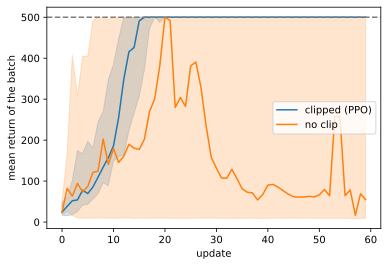

In [10]:
d2l.plot_curves({name: r[:, :, 0] for name, r in runs.items()},
                xlabel='update', ylabel='mean return of the batch',
                reference=500)

With twenty optimization epochs per batch, at least half of the unclipped seeds finish with a return below 100. Repeated unconstrained updates move the policy into a saturated region in which gradients are small, and subsequent batches are then collected by the poor policy. Every clipped seed finishes near the maximum return under the same data and update schedule. The identities of the failed seeds can vary with numerical details, so the comparison concerns the failure rate rather than particular seeds. With fewer epochs or a smaller learning rate, the unclipped variant usually succeeds; clipping is most useful when batch reuse and step size would otherwise produce an excessive policy change.

The clipping rate must be defined carefully. Each update checks every sample once per epoch, and the first epoch begins with $\rho_t=1$ for every sample. We report both the fraction of all per-epoch checks outside the band and the corresponding fraction in the final epoch of each batch:

In [11]:
for name, r in runs.items():
    print(f'{name:>13}: ratio checks outside the band: '
          f'{r[:, :, 1].mean():.1%} across all epochs')
    print(f'{"":>13}  {r[:, :, 4].mean():.1%} at the last epoch '
          f'of each batch')

clipped (PPO): ratio checks outside the band: 5.3% across all epochs
               5.5% at the last epoch of each batch
      no clip: ratio checks outside the band: 21.6% across all epochs
               30.0% at the last epoch of each batch


For the clipped runs, both counts are near one check in twenty. Clipping sets
the surrogate gradient to zero for samples whose ratios have crossed the
relevant boundary. In the unclipped control, ratios cross the band about three
times as often overall and continue to move across repeated epochs.

### Training Diagnostics

that section closed with the warning that the loss carries no signal here and that what deserves watching are diagnostics of the *update*. This section is where that advice becomes concrete, because the run above already returned every number an engineer would watch. Within a batch:

entropy: 0.64 over the first five updates, 0.26 over the last five


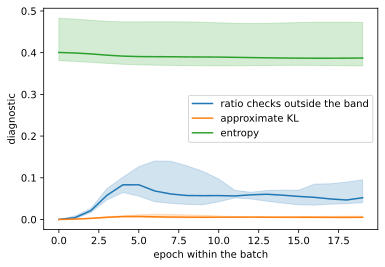

In [12]:
d2l.plot_curves({'ratio checks outside the band': diag[:, :, :, 0].mean(1),
                 'approximate KL': diag[:, :, :, 1].mean(1),
                 'entropy': diag[:, :, :, 2].mean(1)},
                xlabel='epoch within the batch', ylabel='diagnostic')
print(f'entropy: {diag[:, :5, :, 2].mean():.2f} over the first five '
      f'updates, {diag[:, -5:, :, 2].mean():.2f} over the last five')

Within each batch, the approximate KL divergence and the fraction outside the clipping band begin at zero and increase during the first few epochs. They then level off because samples beyond the band no longer contribute gradients in the favorable direction. Most policy movement therefore occurs early in the batch. Across updates, policy entropy decreases from about $0.65$ to $0.25$ nats. The entropy bonus slows this concentration but does not prevent it; that section studies the corresponding regularized objective directly.

The distribution behind those summary fractions is worth one look. Take two fresh identical agents at the *start* of training, where drift is largest, give both the same batch, the same frozen advantages and log-probabilities, and spend twenty passes with the clip on in one and off in the other, reading every ratio after each pass:

In [13]:
probe = {True: cartpole_agent(2), False: cartpole_agent(2)}   # twins
env = gym.make('CartPole-v1')
env.reset(seed=2)
batch = d2l.rollout(env, probe[True].act, batch_episodes,
                    np.random.default_rng(2))
adv = d2l.normalize(batch.gae(probe[True].value_np, gamma, lam))
logp_old = probe[True].log_prob_np(batch.obs, batch.act)
rhos = {}
for clip in (True, False):
    R = []
    for _ in range(num_epochs):   # one pass at a time, ratios read after
        ppo_epochs(probe[clip], batch, adv, logp_old, epsilon_clip, 1,
                   entropy_coef, use_clip=clip)
        R.append(np.exp(probe[clip].log_prob_np(batch.obs, batch.act)
                        - logp_old))
    rhos[clip] = np.array(R)

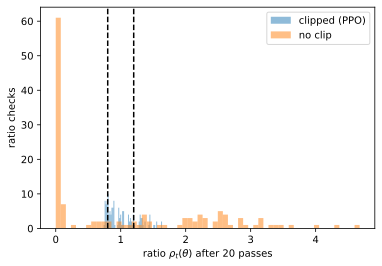

In [14]:
d2l.set_figsize((6, 4))
for clip, name in ((True, 'clipped (PPO)'), (False, 'no clip')):
    d2l.plt.hist(rhos[clip][-1], bins=60, alpha=0.5, label=name)
for edge in (1 - epsilon_clip, 1 + epsilon_clip):
    d2l.plt.axvline(edge, linestyle='--', color='black')
d2l.plt.xlabel(r'ratio $\rho_t(\theta)$ after {} passes'.format(num_epochs))
d2l.plt.ylabel('ratio checks')
d2l.plt.legend()
d2l.plt.show()

After twenty passes, the clipped agent's ratios remain concentrated near one,
with a minority beyond the dashed boundaries. The unclipped ratios are much
more dispersed and many approach zero. The effective sample size
the equation, $N_{\textrm{eff}} = 1 / \sum_s \bar{w}_s^2$ for
normalized weights $\bar{w}$, summarizes this concentration: it equals the
batch size for uniform weights and one when a single weight dominates.

after 20 epochs the batch is worth 95% (clipped (PPO)) vs 42% (no clip) of its 136 steps


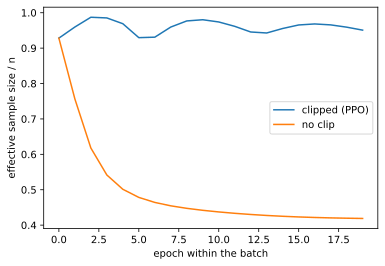

In [15]:
ess = {}
for clip, name in ((True, 'clipped (PPO)'), (False, 'no clip')):
    w = rhos[clip] / rhos[clip].sum(axis=1, keepdims=True)
    ess[name] = 1 / (w ** 2).sum(axis=1) / rhos[clip].shape[1]
d2l.plot_curves(ess, xlabel='epoch within the batch',
                ylabel='effective sample size / n')
print(f'after {num_epochs} epochs the batch is worth '
      + ' vs '.join(f'{v[-1]:.0%} ({k})' for k, v in ess.items())
      + f' of its {len(batch)} steps')

With clipping, the weight distribution remains comparatively flat through the
twentieth epoch. Without clipping, it becomes concentrated enough that the
weight-based effective sample size falls below half the batch.

This is only a ratio-concentration diagnostic. It does not include advantage
signs or magnitudes, temporal dependence, repeated state visits, or states that
the updated policy would visit but the old batch did not. It should therefore
be read alongside approximate KL, clip fraction, entropy, and return rather
than as a count of independent gradient samples.

Finally, we evaluate the clipped policies greedily to remove variability from action sampling:

In [16]:
ac, env = agents['clipped (PPO)'][0], gym.make('CartPole-v1')
env.reset(seed=2)
score = d2l.evaluate(env, ac.act_greedy, num_episodes=100)
print(f'greedy mean return over 100 episodes: {score:.0f}')

greedy mean return over 100 episodes: 500


### Vectorized Collection and Minibatch Updates

The implementation above is deliberately small: it uses one environment, complete episodes, full-batch epochs, and a learning rate of $10^{-2}$. This rate is four to forty times larger than common tuned settings so that the unclipped failure is visible within sixty updates; it should not be treated as a recommended PPO default. Production implementations usually step $N$ environments in parallel for a fixed horizon $T$, producing an $N\times T$ array of transitions. Since this array often ends in the middle of an episode, the value function supplies the continuation value at the truncation boundary, as described in that section.

In [17]:
envs = gym.vector.SyncVectorEnv([lambda: gym.make('CartPole-v1')] * 8)
obs, _ = envs.reset(seed=0)
rng, steps = np.random.default_rng(3), []
for _ in range(32):                       # the fixed 32 x 8 rectangle
    act = np.array([rng.choice(2, p=p) for p in _probs(ac, obs)])
    obs, rew, term, trunc, _ = envs.step(act)
    steps.append((rew, term | trunc))
rew, done = map(np.array, zip(*steps))
print(f'a fixed {rew.shape} rectangle of steps, '
      f'{int(done.sum())} episode boundaries inside it')
print(f'V at the cut, pricing the unrecorded future: '
      f'{ac.value_np(obs).round(0)}')

a fixed (32, 8) rectangle of steps, 0 episode boundaries inside it


V at the cut, pricing the unrecorded future: [100. 100. 100. 100. 100. 100. 100. 100.]


The trained agent does not terminate within 32 steps, so all eight trajectories end at the collection horizon. Their continuation values are close to $1/(1-\gamma)=100$, the discounted value of balancing indefinitely. Without this bootstrap, the truncated data would omit most of its return. Production implementations also shuffle the collected array into a few epochs of minibatches rather than using full-batch passes. The following comparison uses four epochs with minibatches of size 32:

In [18]:
full, mini = cartpole_agent(1), cartpole_agent(1)   # identical twins
env = gym.make('CartPole-v1')
env.reset(seed=1)
batch = d2l.rollout(env, full.act, batch_episodes,
                    np.random.default_rng(1))
adv = d2l.normalize(batch.gae(full.value_np, gamma, lam))
logp_old = full.log_prob_np(batch.obs, batch.act)
ppo_epochs(full, batch, adv, logp_old, epsilon_clip, num_epochs,
           entropy_coef)
idx = np.random.default_rng(1).permutation(len(batch))
for _ in range(4):                  # four passes of minibatches of 32
    for i in range(0, len(idx), 32):
        sl = idx[i:i + 32]
        mb = d2l.Batch(batch.obs[sl], batch.act[sl], batch.rew[sl],
                       batch.next_obs[sl], batch.term[sl], [len(sl)])
        ppo_epochs(mini, mb, adv[sl], logp_old[sl], epsilon_clip, 1,
                   entropy_coef)
print(f'{len(batch)} steps spent as {num_epochs} full-batch passes '
      f'or as {4 * int(np.ceil(len(idx) / 32))} minibatch steps:')
for name, ag in (('full batch', full), ('minibatches', mini)):
    kl = (logp_old - ag.log_prob_np(batch.obs, batch.act)).mean()
    print(f'  {name:>11}: approximate KL from the collecting policy '
          f'{kl:.3f}')

386 steps spent as 20 full-batch passes or as 52 minibatch steps:
   full batch: approximate KL from the collecting policy 0.008
  minibatches: approximate KL from the collecting policy 0.022


The two procedures produce policy changes of similar order. Minibatching reduces memory requirements and improves hardware utilization while adding gradient noise. Each sample's ratio is checked four times rather than twenty, and advantage normalization is commonly recomputed within each minibatch. There is also an update-order difference: our loop completes all critic passes before computing advantages and updating the actor, whereas typical implementations compute advantages once with the pre-update critic and then interleave policy and value losses across minibatches.

### Omitted Implementation Details

The gap between this section's PPO and a production one is a list of small, named decisions, none of which needs new theory:

| What real implementations add | Purpose |
|---|---|
| Learning-rate annealing to zero | reduce late updates as the policy approaches convergence |
| Observation and reward normalization | running estimates hold network inputs and value targets near unit scale on tasks whose raw numbers vary by orders of magnitude |
| Value-loss clipping | the critic gets a band of its own; its measured benefit is disputed, yet nearly every implementation ships it |
| KL-based early stopping | stop the epochs when the measured approximate KL passes a threshold: our diagnostic panel turned into an actuator |
| Orthogonal initialization, small policy head | start the policy near uniform so the first updates cannot blow the ratios out |
| Advantage normalization per minibatch | that section's per-batch step size, recomputed at the granularity the gradient uses |
| Joint policy-and-value minibatch updates | one shuffled pass interleaves both losses; our critic-first, actor-second phases are a teaching choice |

The list is not ours. A community audit collected 37 such implementation details and measured which ones matter [@Huang.Dossa.Raffin.ea.2022]; a controlled study went further and showed that at matched code-level choices PPO and TRPO perform nearly identically, so these details, not the clipped objective, account for much of PPO's practical edge [@Engstrom.Ilyas.Santurkar.ea.2020]; and a large-scale sweep across a quarter-million trained agents reached similarly sober conclusions about which knobs carry the performance [@Andrychowicz.Raichuk.Stanczyk.ea.2021]. The practical instruction a textbook can give is therefore this: when you need a real PPO, read a maintained single-file implementation and diff it against this section; the roughly 300-line `cleanrl/ppo.py` is the standard study text. Every line you do not recognize will be on the list above, and now you know why each is there.

## Summary

Equal parameter steps need not produce equal changes in a policy. Importance sampling corrects expectations when data come from an older policy, but trajectory-level products of ratios can have high variance. The per-step surrogate is a local approximation that retains the old policy's state distribution. TRPO controls this approximation through a divergence constraint and a monotonic-improvement bound. PPO instead clips individual probability ratios; this is simpler but does not inherit the TRPO guarantee. Practical PPO also uses GAE, an entropy bonus, repeated optimization epochs, and diagnostics for KL divergence, clipping, entropy, and effective sample size.

**Experimental scope.** The clipping ablation uses eight seeds per method and framework. With twenty reuse epochs, every clipped run reaches high CartPole return, whereas at least half of the unclipped runs collapse. The exact failure rate and diagnostic values vary across seeds. The implementation uses full batches from a single environment and omits vectorized collection and minibatch updates, so it illustrates the clipped objective rather than reproducing a production PPO system.

## Exercises

1. [conceptual] *One epoch is not PPO.* Show that at $\theta = \theta_{\textrm{old}}$
   every ratio in the equation equals one, and that the gradient of the
   clipped objective there is exactly the policy gradient estimate of
   that section. Predict what the clipped and unclipped variants will
   do at `num_epochs = 1`, before you run the next exercise.
1. [extended] *Reuse against clipping.* Vary `num_epochs` over $\{1, 5, 20\}$
   with and without clipping, three seeds each. Report the fraction of seeds
   that end below a return of 100, and the fraction of ratio checks outside the
   band. Where does the unclipped variant start losing seeds, and does the
   clipped one ever lose one? (About thirty minutes.)
1. [short-code] *How wide should the band be.* Sweep the clipping parameter
   $\epsilon$ over $\{0.02, 0.1, 0.2, 0.5\}$ and one very large value, say
   $10^6$. When does a small $\epsilon$ hurt, what does the large value
   reproduce, and how does the outside-the-band fraction move across the sweep?
1. [short-code] *Minibatch epochs.* Extend `train_ppo` to spend each batch as
   four passes of shuffled minibatches of 32, the deployed default, instead of
   twenty full-batch passes, reusing the slicing pattern of the comparison
   cell. Compare the two on three seeds: learning curves, final approximate KL
   per batch, and the outside-the-band fraction. Which differences are
   statistical and which are bookkeeping?
1. [short-code] *Saturation, and the cure.* Run the normalized REINFORCE of
   that section with a deliberately oversized learning rate,
   $\alpha = 50$, on eight seeds, and record how many seeds ever reach the
   goal. Diagnose the failing seeds with this section's instruments, the
   policy's entropy and the norm of the score, then add an entropy bonus
   $-c \sum_a \pi_\theta(a \mid s) \log \pi_\theta(a \mid s)$ to the
   per-sample objective. How large must $c$ be to change the outcome, and what
   does the same $c$ cost at $\alpha = 2$?
1. [conceptual] *The clip as a step size.* For a two-action softmax policy,
   translate the band $|\rho_t - 1| \leq \epsilon$ into a bound on the change
   in the difference of the two logits, and show that the bound tightens as
   the policy becomes more certain. Explain in one sentence why this is the
   fix that the sigmoid example asked for, and why capping the step in
   $\theta$ would not have been.
1. [conceptual] *Asymmetric bands.* With $\epsilon = 0.2$, compute the largest
   probability each of two actions with $\pi_{\theta_{\textrm{old}}}(a \mid s)
   = 0.01$ and $0.60$ can reach before the clip stops paying for further
   growth, and the smallest each can be driven to before the clip stops the
   penalty. Which side of the band binds exploration, and why does raising
   $\epsilon_{\textrm{high}}$ while keeping $\epsilon_{\textrm{low}}$ fixed
   change the entropy trace of the diagnostic panel rather than just the
   speed of learning?

[Discussions](https://d2l.discourse.group/)